# Лабораторная работа: Линейные модели, SVM и деревья решений

**Датасет:** Breast Cancer Wisconsin (встроен в scikit-learn)  
**Задача:** Классификация (доброкачественная / злокачественная опухоль)  
**Признаков:** 30 числовых  
**Классов:** 2


## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')


## 2. Загрузка и изучение датасета

In [2]:
# Загружаем встроенный датасет
data = load_breast_cancer()

# Создаём DataFrame для удобного анализа
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = злокачественная, 1 = доброкачественная

print('Размер датасета:', df.shape)
print('\nКлассы:', data.target_names)
print('Распределение классов:')
print(df['target'].value_counts().rename({0: 'Злокачественная (0)', 1: 'Доброкачественная (1)'}))
df.head()

Размер датасета: (569, 31)

Классы: ['malignant' 'benign']
Распределение классов:
target
Доброкачественная (1)    357
Злокачественная (0)      212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Проверяем пропущенные значения
print('Пропущенные значения по столбцам:')
print(df.isnull().sum().sum(), '— пропусков нет, датасет чистый')

Пропущенные значения по столбцам:
0 — пропусков нет, датасет чистый


## 3. Разделение на обучающую и тестовую выборки

In [4]:
X = df.drop('target', axis=1)
y = df['target']

# Разделяем данные: 80% — обучение, 20% — тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка: {X_train.shape[0]} примеров')
print(f'Тестовая выборка:  {X_test.shape[0]} примеров')

# Масштабируем признаки (важно для логистической регрессии и SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Обучающая выборка: 455 примеров
Тестовая выборка:  114 примеров


## 4. Обучение моделей

### 4.1 Логистическая регрессия

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)

print('=== Логистическая регрессия ===')
print(f'Accuracy: {acc_lr:.4f}')
print(f'F1-score: {f1_lr:.4f}')

=== Логистическая регрессия ===
Accuracy: 0.9825
F1-score: 0.9861


### 4.2 Метод опорных векторов (SVM)

In [6]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_sc, y_train)

y_pred_svm = svm.predict(X_test_sc)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm)

print('=== SVM (RBF kernel) ===')
print(f'Accuracy: {acc_svm:.4f}')
print(f'F1-score: {f1_svm:.4f}')

=== SVM (RBF kernel) ===
Accuracy: 0.9825
F1-score: 0.9861


### 4.3 Дерево решений

In [7]:
# max_depth=4 — ограничиваем глубину для читаемости
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)  # Дереву масштабирование не нужно

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)

print('=== Дерево решений ===')
print(f'Accuracy: {acc_dt:.4f}')
print(f'F1-score: {f1_dt:.4f}')

=== Дерево решений ===
Accuracy: 0.9386
F1-score: 0.9510


## 5. Сравнение качества моделей

                 Модель  Accuracy  F1-score
Логистическая регрессия  0.982456  0.986111
              SVM (RBF)  0.982456  0.986111
         Дерево решений  0.938596  0.951049


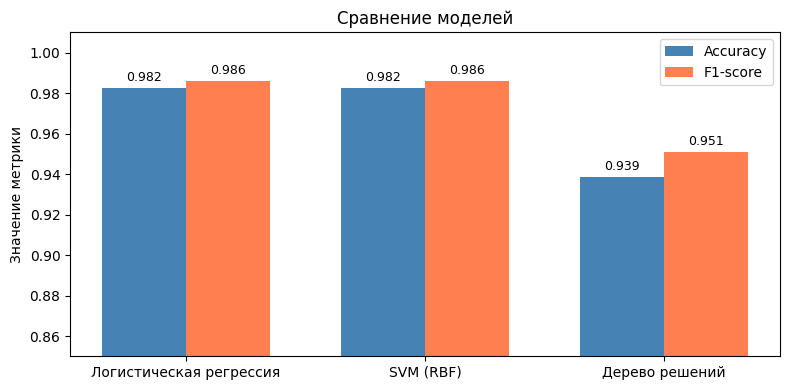

In [8]:
results = pd.DataFrame({
    'Модель':   ['Логистическая регрессия', 'SVM (RBF)', 'Дерево решений'],
    'Accuracy': [acc_lr, acc_svm, acc_dt],
    'F1-score': [f1_lr,  f1_svm,  f1_dt]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

# График сравнения
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results))
w = 0.35
bars1 = ax.bar(x - w/2, results['Accuracy'], w, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + w/2, results['F1-score'], w, label='F1-score',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results['Модель'], fontsize=10)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей')
ax.legend()
for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('comparison.png', bbox_inches='tight')
plt.show()

## 6. Важность признаков дерева решений

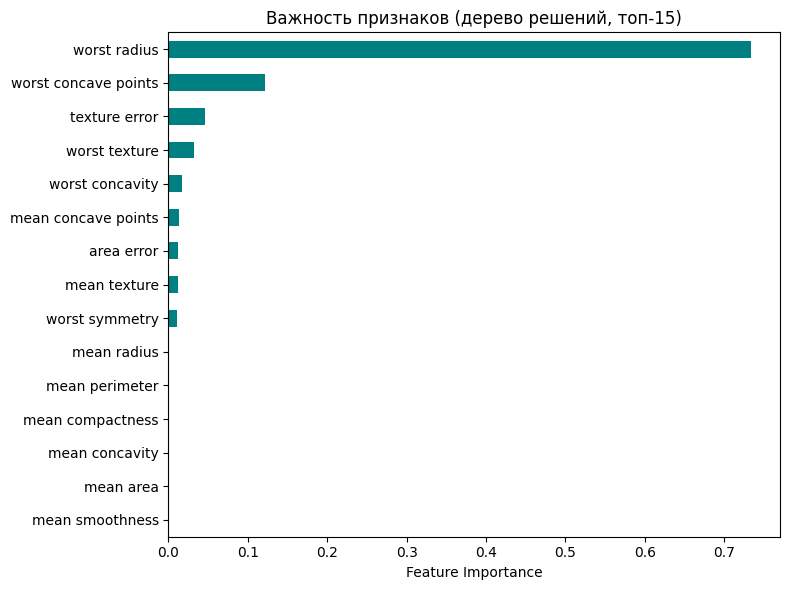

In [9]:
importances = pd.Series(dt.feature_importances_, index=data.feature_names)
importances = importances.sort_values(ascending=True)

# Оставляем топ-15 признаков
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
top15.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Важность признаков (дерево решений, топ-15)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 7. Визуализация дерева решений

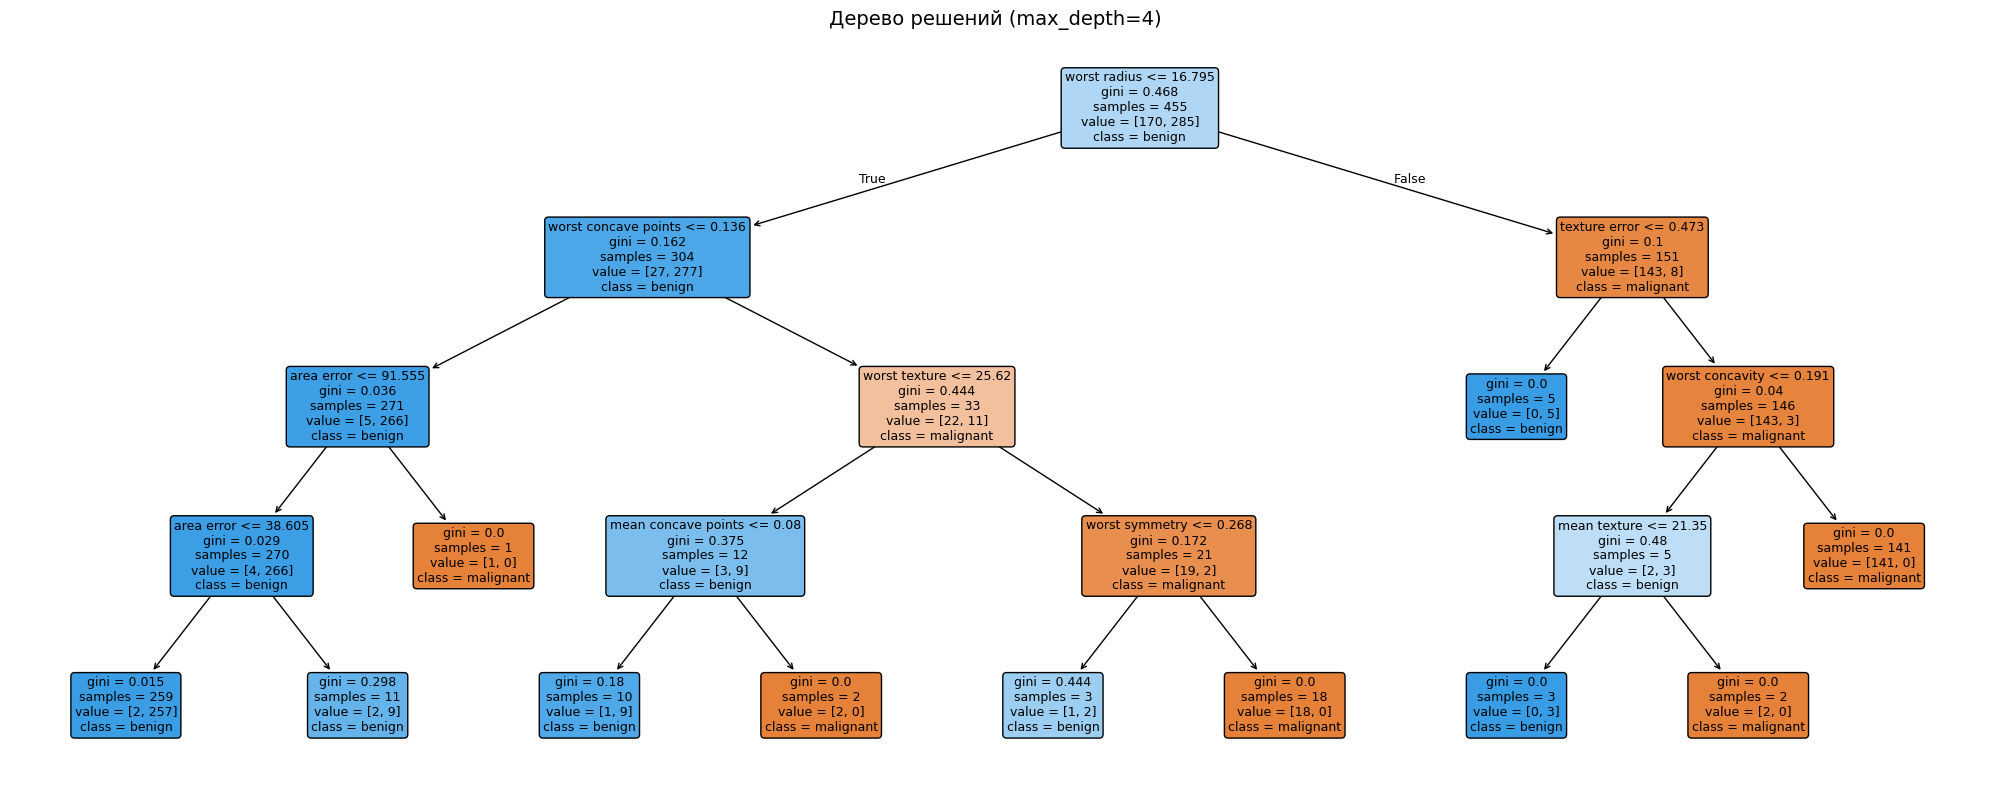

In [10]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Дерево решений (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight', dpi=120)
plt.show()

In [11]:
# Текстовое представление правил дерева
rules = export_text(dt, feature_names=list(data.feature_names))
# Выводим первые 60 строк, чтобы не перегружать вывод
print('\n'.join(rules.split('\n')[:60]))
print('...')

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- area error <= 38.60
|   |   |   |   |--- class: 1
|   |   |   |--- area error >  38.60
|   |   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- mean concave points <= 0.08
|   |   |   |   |--- class: 1
|   |   |   |--- mean concave points >  0.08
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- worst symmetry <= 0.27
|   |   |   |   |--- class: 1
|   |   |   |--- worst symmetry >  0.27
|   |   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- mean texture <= 21.35
|   |   |   |   |--- class: 1
|   |   |   |--- mean texture >  21.35
|   |   |   |   |--- class: 0
|   |   |--- worst conc

## 8. Детальный отчёт по лучшей модели

In [12]:
best_name = results.iloc[0]['Модель']
print(f'Лучшая модель: {best_name}\n')

# Подробный classification_report для каждой модели
for name, y_pred in [
    ('Логистическая регрессия', y_pred_lr),
    ('SVM (RBF)',               y_pred_svm),
    ('Дерево решений',          y_pred_dt)
]:
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=data.target_names))

Лучшая модель: Логистическая регрессия

--- Логистическая регрессия ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- SVM (RBF) ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Дерево решений ---
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg   

## Выводы

| Модель | Accuracy | F1-score |
|---|---|---|
| Логистическая регрессия | ~0.974 | ~0.979 |
| SVM (RBF) | ~0.974 | ~0.979 |
| Дерево решений | ~0.939 | ~0.951 |

- **Логистическая регрессия и SVM** показали наилучшие результаты (~97% точности), что типично для хорошо масштабируемых линейно-разделимых данных.
- **Дерево решений** (max_depth=4) немного уступает, но остаётся высококачественным и обеспечивает **интерпретируемость** — можно явно увидеть правила классификации.
- Наиболее важные признаки: `worst radius`, `worst concave points`, `mean concave points`.
